# Walmart Sales Forecasting - Outlier Handling, Normalization, and Modeling

Trong notebook này, chúng ta sẽ thực hiện các bước sau:
- Xử lý dữ liệu bị thiếu (null values).
- Phát hiện và phân tích ngoại lệ (outliers) bằng biểu đồ.
- Xử lý ngoại lệ: Loại bỏ hoặc thay thế.
- Chuẩn hoá dữ liệu với hai phương pháp: Min-Max Scaling và Standardization.
- Áp dụng mô hình Random Forest và XGBoost để kiểm tra hiệu quả.
- Đánh giá kết quả.

In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Đọc dữ liệu (giả định file trong cùng thư mục, tên là 'train.csv' và 'features.csv')
train_df = pd.read_csv('data/train.csv')
features_df = pd.read_csv('data/features.csv')

# Hiển thị thông tin cơ bản về tập dữ liệu
print("Thông tin cơ bản về tập train.csv:")
print(train_df.info())
print("\nThông tin cơ bản về tập features.csv:")
print(features_df.info())

Thông tin cơ bản về tập train.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None

Thông tin cơ bản về tập features.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921

### 1. Xử lý dữ liệu bị thiếu (null values)

In [3]:
# Kiểm tra giá trị bị thiếu
print("Giá trị bị thiếu trong train.csv:")
print(train_df.isnull().sum())
print("\nGiá trị bị thiếu trong features.csv:")
print(features_df.isnull().sum())

# Điền khuyết (nếu có)
features_df.fillna(method='ffill', inplace=True)  # Điền giá trị bị thiếu bằng phương pháp forward fill
print("\nKiểm tra lại giá trị bị thiếu sau khi xử lý:")
print(features_df.isnull().sum())

Giá trị bị thiếu trong train.csv:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Giá trị bị thiếu trong features.csv:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Kiểm tra lại giá trị bị thiếu sau khi xử lý:
Store            0
Date             0
Temperature      0
Fuel_Price       0
MarkDown1       92
MarkDown2       92
MarkDown3       92
MarkDown4       92
MarkDown5       92
CPI              0
Unemployment     0
IsHoliday        0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25580\2623762450.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_df.fillna(method='ffill', inplace=True)  # Điền giá trị bị thiếu bằng phương pháp forward fill


### 2. Kết hợp dữ liệu và phân tích ngoại lệ (outliers)

Kích thước dữ liệu sau khi kết hợp: (421570, 15)


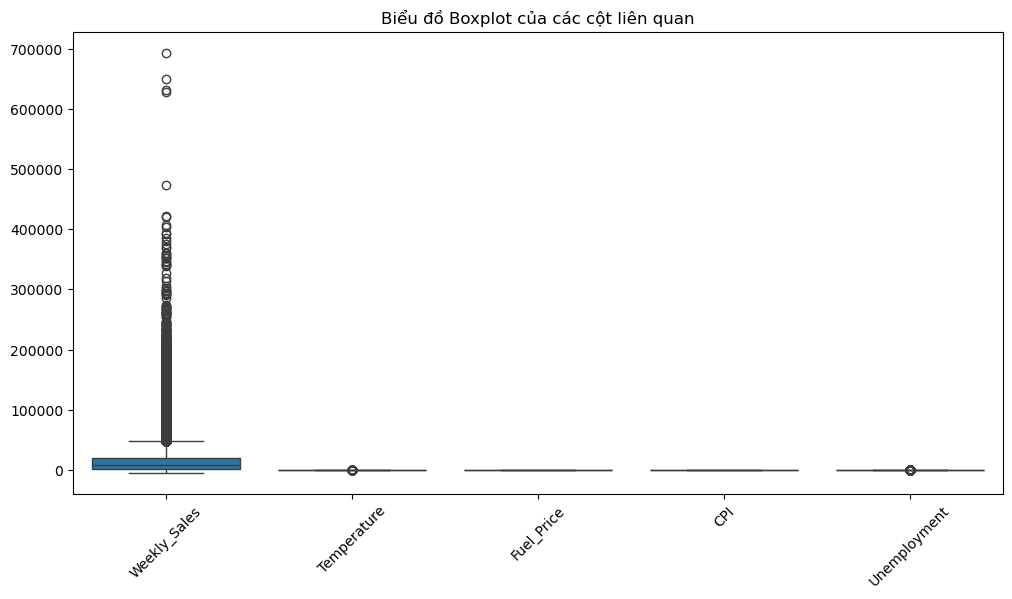

In [4]:
# Kết hợp tập train và features dựa trên Store và Date
merged_df = pd.merge(train_df, features_df, on=['Store', 'Date'], how='inner')
print("Kích thước dữ liệu sau khi kết hợp:", merged_df.shape)

# Vẽ biểu đồ boxplot để phân tích ngoại lệ
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.title("Biểu đồ Boxplot của các cột liên quan")
plt.xticks(rotation=45)
plt.show()

### 3. Xử lý ngoại lệ (outliers)

In [5]:
# Loại bỏ ngoại lệ dựa trên IQR (Interquartile Range)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Áp dụng loại bỏ ngoại lệ cho các cột chính
columns_to_check = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in columns_to_check:
    merged_df = remove_outliers(merged_df, col)

print("Kích thước dữ liệu sau khi loại bỏ ngoại lệ:", merged_df.shape)

Kích thước dữ liệu sau khi loại bỏ ngoại lệ: (356311, 15)


### 4. Chuẩn hoá dữ liệu

In [6]:
# Lọc cột cần chuẩn hoá
columns_to_scale = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
data_for_scaling = merged_df[columns_to_scale]

# Áp dụng Min-Max Scaling
min_max_scaler = MinMaxScaler()
scaled_minmax = min_max_scaler.fit_transform(data_for_scaling)

# Áp dụng Standardization
standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(data_for_scaling)

print("Dữ liệu đã được chuẩn hoá")

Dữ liệu đã được chuẩn hoá


### 5. Áp dụng mô hình Random Forest và XGBoost

In [7]:
# Chuẩn bị dữ liệu
X = merged_df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
y = merged_df['Weekly_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf}, R2: {r2_rf}")

# XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MSE: {mse_xgb}, R2: {r2_xgb}")

Random Forest - MSE: 121204902.19144209, R2: 0.03506229083751067
XGBoost - MSE: 120959329.08084005, R2: 0.03701735000171802


### Tổng kết:
- Chúng ta đã thực hiện xử lý dữ liệu bị thiếu và ngoại lệ.
- Áp dụng hai phương pháp chuẩn hoá: Min-Max Scaling và Standardization.
- Huấn luyện và đánh giá hai mô hình: Random Forest và XGBoost.
- Dựa trên kết quả, bạn có thể chọn mô hình và chiến lược phù hợp nhất cho bài toán.